# 1. import necessary libraries

In [17]:
import pandas as pd
from matplotlib import pyplot as plt

## 2. import data

In [61]:
weight_height_data = pd.read_csv('weight-height.csv')

In [62]:
weight_height_data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


## 3.Data Understanding

In [63]:
weight_height_data.shape

(10000, 3)

In [64]:
weight_height_data.isnull().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [65]:
weight_height_data.dtypes

Gender     object
Height    float64
Weight    float64
dtype: object

# 4. Data preparation

### Let's do Feature Engineering 
- it is nothing but a concept of whatever you do with features, we call it as Feature Engineering.
- Feature Deletion
- Feature Addition
- Feature Selection
- Feature Decomposition
- Feature Transformation

### We are interested to convert units of Height from inches and Weight from pounds to kg

In [66]:
weight_height_data_copied = weight_height_data.copy()

In [67]:
weight_height_data_copied

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


weight_height_data_copied()

In [68]:
del weight_height_data_copied['Gender']

In [69]:
weight_height_data_copied

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
9995,66.172652,136.777454
9996,67.067155,170.867906
9997,63.867992,128.475319
9998,69.034243,163.852461


In [70]:
weight_height_data_copied['Height_cm'] = weight_height_data_copied['Height']*2.54

In [71]:
weight_height_data_copied

,Height,Weight,Height_cm
0,73.847017,241.893563,187.571423
1,68.781904,162.310473,174.706036
2,74.110105,212.740856,188.239668
3,71.730978,220.042470,182.196685
4,69.881796,206.349801,177.499761
...,...,...,...
9995,66.172652,136.777454,168.078536
9996,67.067155,170.867906,170.350573
9997,63.867992,128.475319,162.224700
9998,69.034243,163.852461,175.346978


In [72]:
weight_height_data_copied['weight_kg'] = weight_height_data_copied['Weight']/2.205

In [73]:
weight_height_data_copied

,Height,Weight,Height_cm,weight_kg
0,73.847017,241.893563,187.571423,109.702296
1,68.781904,162.310473,174.706036,73.610192
2,74.110105,212.740856,188.239668,96.481114
3,71.730978,220.042470,182.196685,99.792504
4,69.881796,206.349801,177.499761,93.582676
...,...,...,...,...
9995,66.172652,136.777454,168.078536,62.030591
9996,67.067155,170.867906,170.350573,77.491114
9997,63.867992,128.475319,162.224700,58.265451
9998,69.034243,163.852461,175.346978,74.309506


In [74]:
weight_height_data_copied.drop(labels=['Height','Weight'],axis=1,inplace=True)

In [75]:
weight_height_data_copied

,Height_cm,weight_kg
0,187.571423,109.702296
1,174.706036,73.610192
2,188.239668,96.481114
3,182.196685,99.792504
4,177.499761,93.582676
...,...,...
9995,168.078536,62.030591
9996,170.350573,77.491114
9997,162.224700,58.265451
9998,175.346978,74.309506


## Let's Perform Assumptions Test

#### Assumption 1 : Normality Test

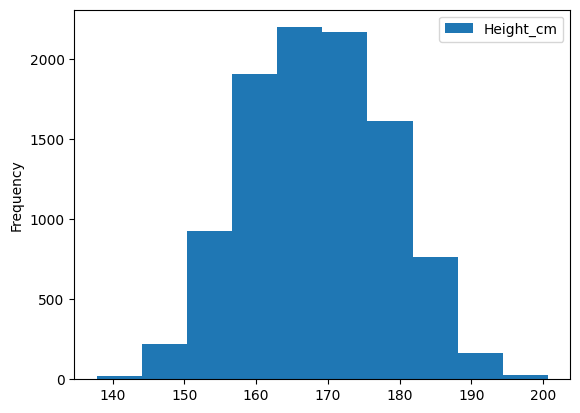

In [76]:
weight_height_data_copied.plot(kind = 'hist',x = 'weight_kg')
plt.show()

### Assumption 2: Linearity Test

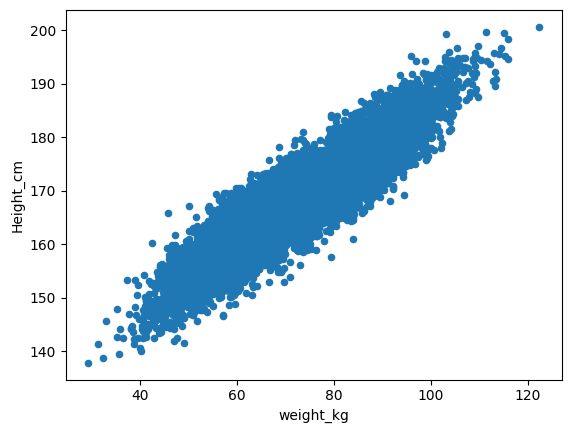

In [77]:
weight_height_data_copied.plot(x ='weight_kg' ,y = 'Height_cm' ,kind = 'scatter')
plt.show()

### Assumption 3 : Multicollinearity

In [78]:
weight_height_data_copied.corr()

,Height_cm,weight_kg
Height_cm,1.000000,0.924756
weight_kg,0.924756,1.000000


### Assumption 4: No Auto Regression

### Assumption 5 : Homoscadasticity Test
### Assumption 6: Zero Residual Mean Test

**Note : These 2 tests will be Performed post model Training**

## 5. Model building 

In [79]:
X = weight_height_data_copied[['weight_kg']]
y = weight_height_data_copied[['Height_cm']]

## 6. Model Training

In [80]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\MOHANASUNDARAM.M\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


# 7. Model Testing 

In [81]:
#  slope value
linear_model.coef_

array([[0.62062922]])

In [82]:
# intercept value
linear_model.intercept_

array([123.13387264])

### Manual Testing

In [86]:
# y = mx+c
# if weight is 95kg, what will be the Height?
(0.62062922*95) + 123.13387264

182.09364854

In [87]:
# If weight is 75kg, what will be the Height?
(0.62062922*75) + 123.13387264

169.68106414

In [88]:
# If weight is 110kg, what will be the Height?
(0.62062922*110) + 123.13387264

191.40308684000001

## Automatic Prediction 

In [99]:
# X_test = pd.DataFrame(data = [95,75,110])
# X_test
# linear_model.predict([95])

y_pred = linear_model.predict(X)
# y_pred = pd.DataFrame(y_pred)
y_pred

array([[191.21832319],
       [168.81850845],
       [183.01287094],
       ...,
       [159.29511386],
       [169.25252357],
       [155.12206037]], shape=(10000, 1))

In [100]:
linear_model.predict(X_test)

C:\Users\MOHANASUNDARAM.M\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[182.09364855],
       [169.68106414],
       [191.40308685]])

# 8. Model Evaluation 

In [103]:
# y
error = y - y_pred
error

,Height_cm
0,-3.646900
1,5.887528
2,5.226797
3,-2.871331
4,-3.714254
...,...
9995,6.446666
9996,-0.876549
9997,2.929586
9998,6.094454


In [104]:
error.mean()

Height_cm   -1.995204e-14
dtype: float64

In [97]:
error = y - y_pred
error

,Height_cm,0
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
9995,NaN,NaN
9996,NaN,NaN
9997,NaN,NaN
9998,NaN,NaN


## Let's Check Assumption 5 : Homoscadasticity Test
- **It's test between Input ans The error**

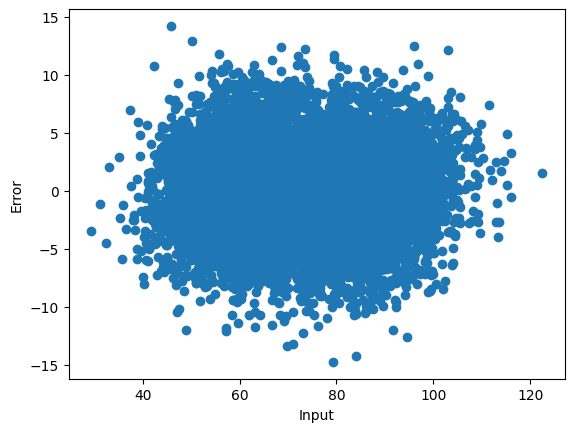

In [107]:
plt.scatter(x = weight_height_data_copied['weight_kg'] , y = error)
plt.xlabel('Input')
plt.ylabel('Error')
plt.show()

### Assumption 6 : Zero Residual Mean Test across the Fitted Line
- **It is a plot betweeen Actual Output and Predicted output**

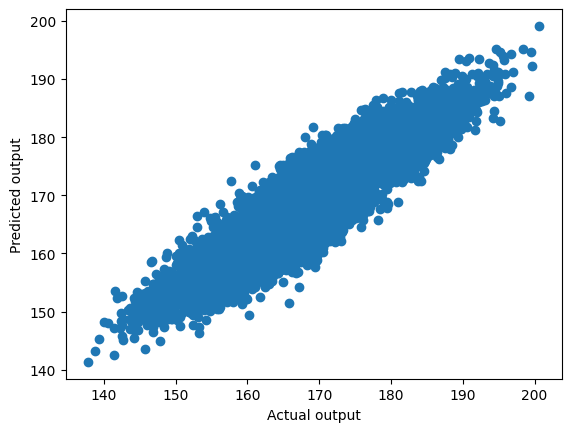

In [108]:
plt.scatter(x = y , y = y_pred)
plt.xlabel('Actual output')
plt.ylabel('Predicted output')
plt.show()

# This is Model is pretty good, Now it is ready for production

# 9. Model Deployment

In [109]:
from pickle import dump

In [110]:
dump(linear_model,open('height_intelligence.pkl','wb')) # write bytes

In [111]:
from pickle import load

In [115]:
loaded_intelligence = load(open('height_intelligence.pkl','rb')) # read bytes

In [116]:
loaded_intelligence.predict(X_test)

C:\Users\MOHANASUNDARAM.M\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[182.09364855],
       [169.68106414],
       [191.40308685]])

# THE END!